# NLP: Анализ тональности твитов (Sentiment Analysis)

## Описание задачи

Датасет содержит твиты с метками тональности:
- `positive` — позитивный твит
- `negative` — негативный твит
- `neutral` — нейтральный твит

Задача — научить модель определять тональность текста.

## Шаг 1. Установка и импорт зависимостей

In [28]:
!pip install scikit-learn nltk pandas numpy wordcloud gensim -q
!pip install keras tensorflow -q
!pip install lime --no-build-isolation -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [29]:
import sklearn
import nltk
import pandas as pd
import numpy as np
import re
import itertools
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches

from nltk.tokenize import RegexpTokenizer
from wordcloud import WordCloud
from pylab import rcParams

nltk.download('punkt', quiet=True)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 40
LABELS = ['negative', 'neutral', 'positive']

## Шаг 2. Загрузка и проверка данных

In [30]:
url = 'Tweets.csv'
questions = pd.read_csv(url, encoding='utf-8')
questions.columns = ['textID', 'text', 'selected_text', 'sentiment']
questions.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [31]:
questions.tail()

,textID,text,selected_text,sentiment
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive
27480,6f7127d9d7,All this flirting going on - The ATG smiles...,All this flirting going on - The ATG smiles. Y...,neutral


In [ ]:
questions.describe()

,textID,text,selected_text,sentiment
count,27481,27480,27480,27481
unique,27481,27480,22463,3
top,6f7127d9d7,All this flirting going on - The ATG smiles...,good,neutral
freq,1,1,199,11118


## Шаг 2. Очистка данных (Sanitizing input)

Правило номер один: «Ваша модель сможет стать лишь настолько хороша, насколько хороши ваши данные»

Выполним следующие шаги очистки:
1. Удалим URL-адреса и упоминания (@user)
2. Удалим нерелевантные символы
3. Переведём текст в нижний регистр

In [32]:
def standardize_text(df, text_field):
    df[text_field] = df[text_field].str.replace(r"http\S+", "", regex=True)
    df[text_field] = df[text_field].str.replace(r"http", "", regex=True)
    df[text_field] = df[text_field].str.replace(r"@\S+", "", regex=True)
    df[text_field] = df[text_field].str.replace(r"[^A-Za-z0-9(),!?@\'\`\"\_\n]", " ", regex=True)
    df[text_field] = df[text_field].str.replace(r"@", "at", regex=True)
    df[text_field] = df[text_field].str.lower()
    return df

questions = standardize_text(questions, "text")
questions.to_csv("clean_data.csv", index=False)
questions.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"i`d have responded, if i were going","I`d have responded, if I were going",neutral
1,549e992a42,sooo sad i will miss you here in san diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"sons of , why couldn`t they put them on t...","Sons of ****,",negative


In [33]:
clean_questions = pd.read_csv("clean_data.csv")
clean_questions = clean_questions.dropna(subset=["text"])
clean_questions.tail()

,textID,text,selected_text,sentiment
27476,4eac33d1c0,wish we could come see u on denver husband l...,d lost,negative
27477,4f4c4fc327,i`ve wondered about rake to the client has ...,", don`t force",negative
27478,f67aae2310,yay good for both of you enjoy the break y...,Yay good for both of you.,positive
27479,ed167662a5,but it was worth it,But it was worth it ****.,positive
27480,6f7127d9d7,all this flirting going on the atg smiles...,All this flirting going on - The ATG smiles. Y...,neutral


### Анализ данных

Посмотрим на баланс классов

In [ ]:
clean_questions.groupby("sentiment").count()

,textID,text,selected_text
sentiment,,,
negative,7781,7781,7781
neutral,11116,11116,11116
positive,8582,8582,8582


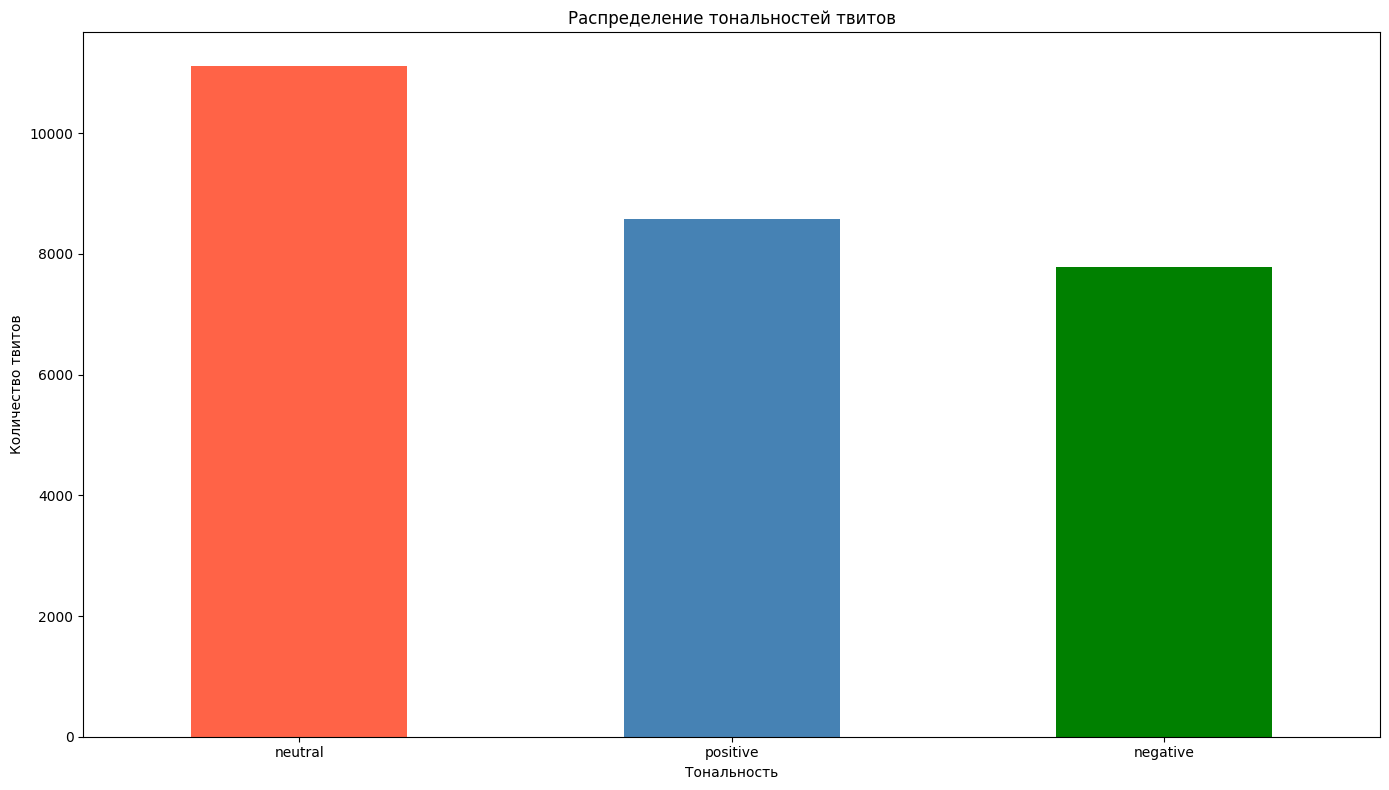

In [34]:
# Визуализация баланса классов
counts = clean_questions['sentiment'].value_counts()
counts.plot(kind='bar', rot=0, color=['tomato', 'steelblue', 'green'])
plt.title('Распределение тональностей твитов')
plt.xlabel('Тональность')
plt.ylabel('Количество твитов')
plt.tight_layout()
plt.show()

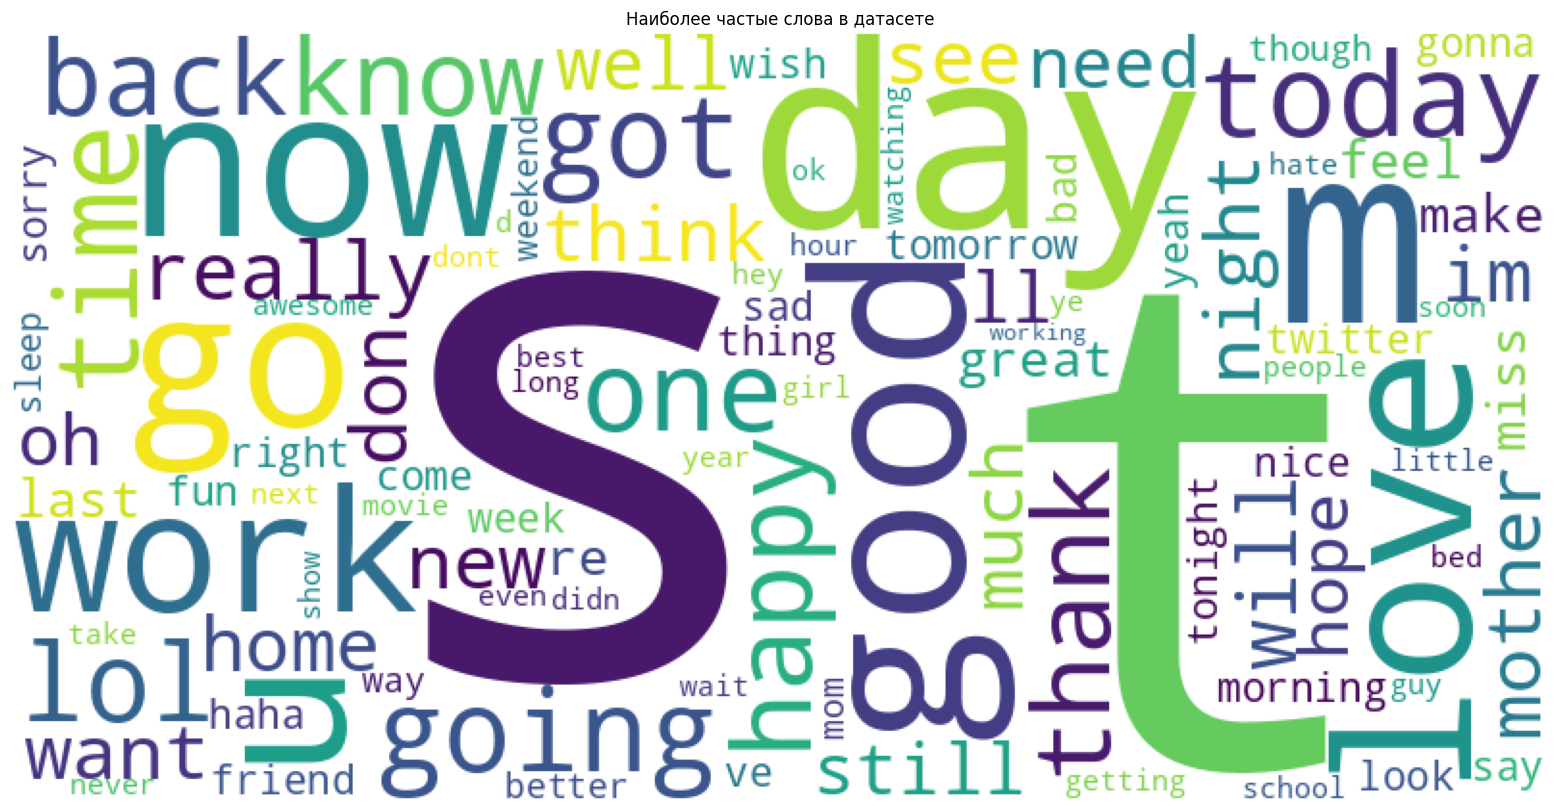

In [35]:
# Облако слов по всему датасету
a = " ".join(clean_questions["text"].dropna())

en_cloud = WordCloud(max_words=100, background_color='white',
                     width=800, height=400,
                     collocations=False).generate(a)
fig = plt.figure(figsize=(20, 10))
plt.imshow(en_cloud)
plt.axis('off')
plt.title('Наиболее частые слова в датасете')
plt.show()

## Шаг 3. Подготовка данных: токенизация

In [36]:
tokenizer = RegexpTokenizer(r'\w+')

clean_questions["tokens"] = clean_questions["text"].apply(tokenizer.tokenize)
clean_questions.head()

,textID,text,selected_text,sentiment,tokens
0,cb774db0d1,"i`d have responded, if i were going","I`d have responded, if I were going",neutral,"[i, d, have, responded, if, i, were, going]"
1,549e992a42,sooo sad i will miss you here in san diego!!!,Sooo SAD,negative,"[sooo, sad, i, will, miss, you, here, in, san,..."
2,088c60f138,my boss is bullying me,bullying me,negative,"[my, boss, is, bullying, me]"
3,9642c003ef,what interview! leave me alone,leave me alone,negative,"[what, interview, leave, me, alone]"
4,358bd9e861,"sons of , why couldn`t they put them on t...","Sons of ****,",negative,"[sons, of, why, couldn, t, they, put, them, on..."


In [37]:
try:
    from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.utils import to_categorical
except ImportError:
    from keras.preprocessing.text import Tokenizer as KerasTokenizer
    from keras.preprocessing.sequence import pad_sequences
    from keras.utils import to_categorical

all_words = [word for tokens in clean_questions["tokens"] for word in tokens]
sentence_lengths = [len(tokens) for tokens in clean_questions["tokens"]]
VOCAB = sorted(list(set(all_words)))
print("%s слов всего, размер словаря: %s" % (len(all_words), len(VOCAB)))
print("Максимальная длина предложения: %s" % max(sentence_lengths))

363305 слов всего, размер словаря: 25033
Максимальная длина предложения: 37


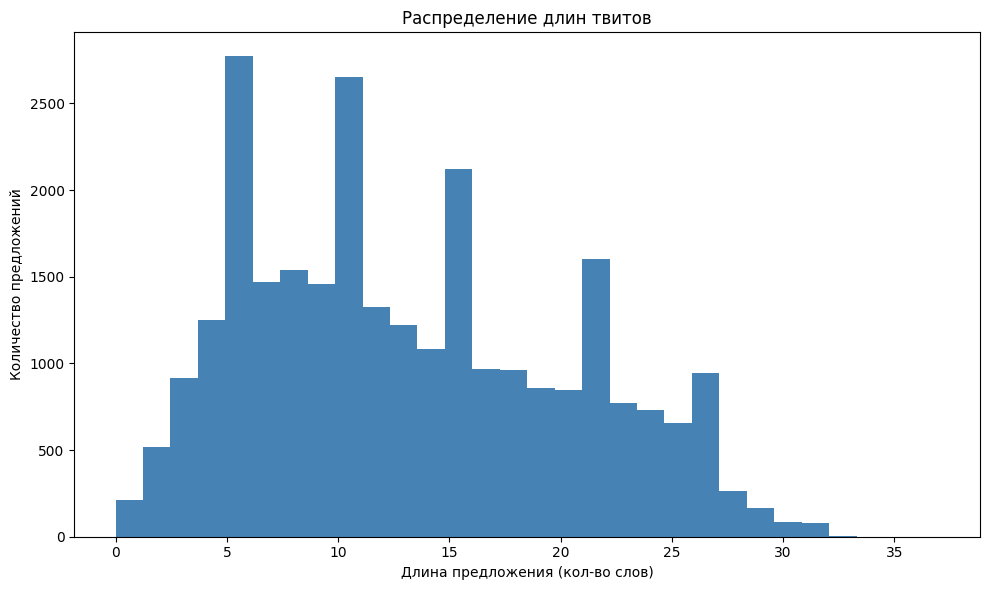

In [38]:
fig = plt.figure(figsize=(10, 6))
plt.xlabel('Длина предложения (кол-во слов)')
plt.ylabel('Количество предложений')
plt.title('Распределение длин твитов')
plt.hist(sentence_lengths, bins=30, color='steelblue')
plt.tight_layout()
plt.show()

## Шаг 4. Классификация

### 4.1 Bag of Words (Мешок слов)

Самый простой способ представить текст числами: каждое слово словаря — отдельное измерение, значение — количество вхождений слова в предложение.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

def cv(data):
    count_vectorizer = CountVectorizer()
    emb = count_vectorizer.fit_transform(data)
    return emb, count_vectorizer

list_corpus = clean_questions["text"].tolist()
list_labels = clean_questions["sentiment"].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    list_corpus, list_labels,
    test_size=0.2, random_state=RANDOM_SEED, stratify=list_labels
)

X_train_counts, count_vectorizer = cv(X_train)
X_test_counts = count_vectorizer.transform(X_test)

print("Размер обучающей выборки:", len(X_train))
print("Размер тестовой выборки:", len(X_test))

Размер обучающей выборки: 21983
Размер тестовой выборки: 5496


### Визуализация векторных представлений (LSA / TruncatedSVD)

Поскольку словарь содержит тысячи слов, напрямую визуализировать векторы нельзя. Используем TruncatedSVD для проекции в 2D.

/tmp/ipykernel_5884/2946992340.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("tab10", len(unique_labels))


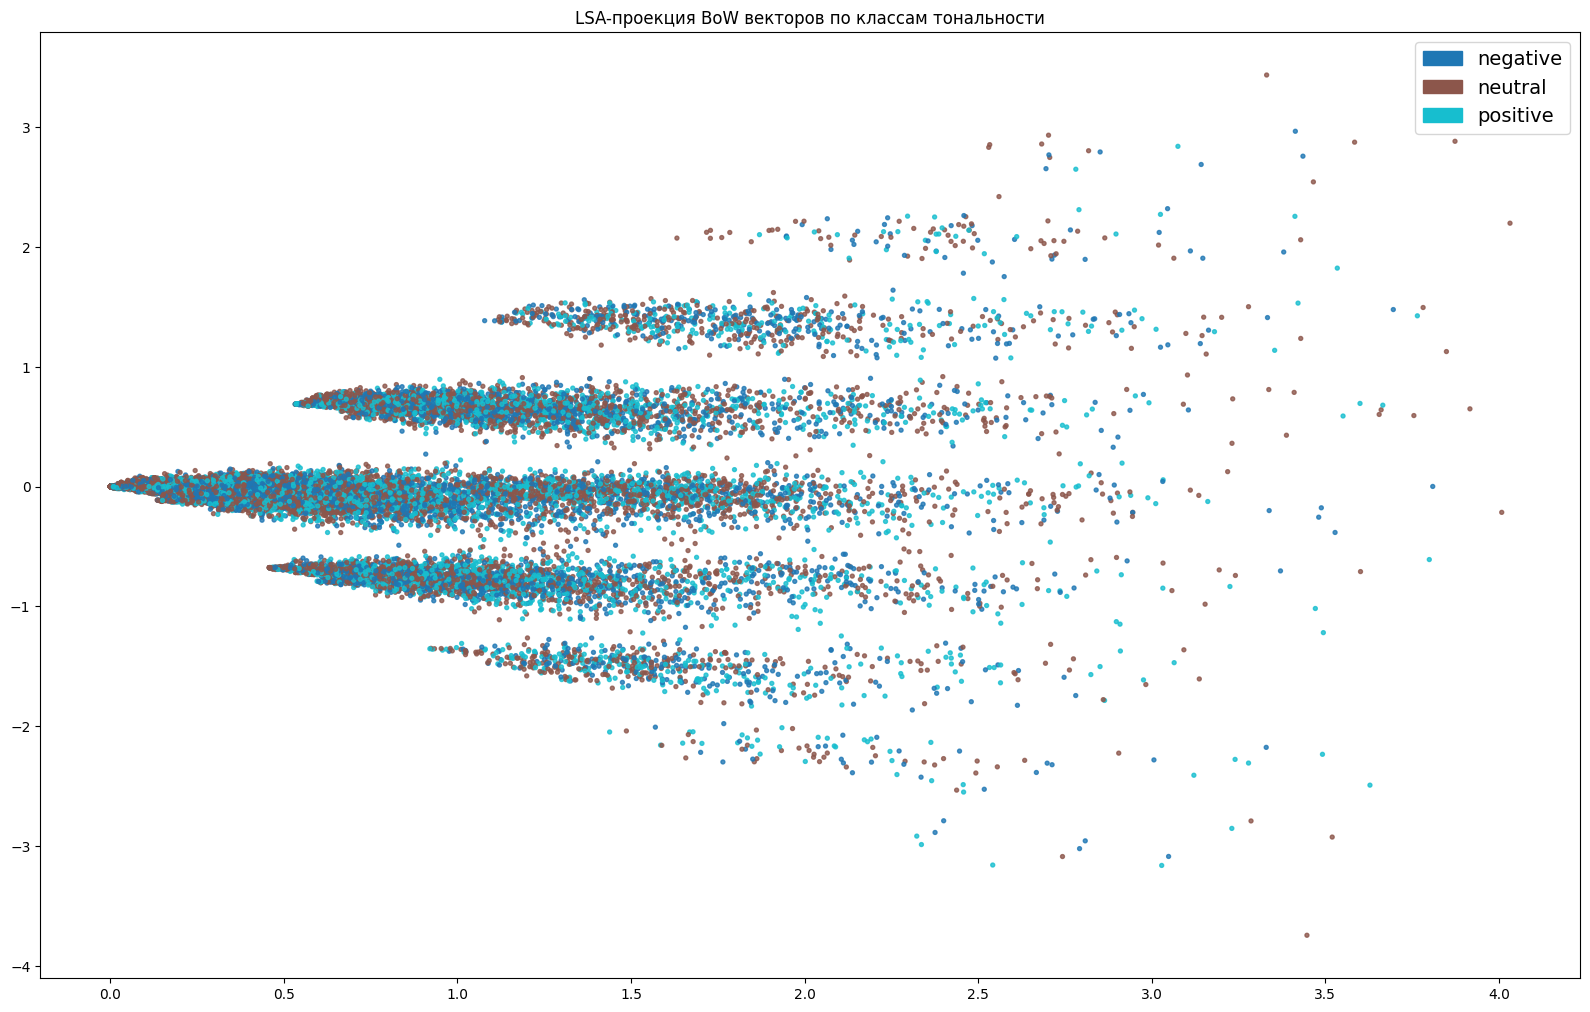

In [40]:
from sklearn.decomposition import TruncatedSVD

def plot_LSA(test_data, test_labels, plot=True):
    lsa = TruncatedSVD(n_components=2, random_state=RANDOM_SEED)
    lsa_scores = lsa.fit_transform(test_data)

    unique_labels = sorted(set(test_labels))
    color_mapper = {label: idx for idx, label in enumerate(unique_labels)}
    color_column = [color_mapper[label] for label in test_labels]

    if plot:
        cmap = matplotlib.cm.get_cmap("tab10", len(unique_labels))
        plt.scatter(lsa_scores[:, 0], lsa_scores[:, 1], s=8, alpha=.8,
                    c=color_column, cmap=cmap)
        handles = [mpatches.Patch(color=cmap(i), label=label)
                   for i, label in enumerate(unique_labels)]
        plt.legend(handles=handles, prop={'size': 14})
        plt.tight_layout()

fig = plt.figure(figsize=(16, 10))
plot_LSA(X_train_counts, y_train)
plt.title('LSA-проекция BoW векторов по классам тональности')
plt.show()

### Логистическая регрессия на BoW

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report, confusion_matrix)

def get_metrics(y_test, y_predicted):
    precision = precision_score(y_test, y_predicted, average='weighted')
    recall = recall_score(y_test, y_predicted, average='weighted')
    f1 = f1_score(y_test, y_predicted, average='weighted')
    accuracy = accuracy_score(y_test, y_predicted)
    return accuracy, precision, recall, f1

clf = LogisticRegression(C=30.0, class_weight='balanced', solver='lbfgs',
                         max_iter=1000, random_state=RANDOM_SEED)
clf.fit(X_train_counts, y_train)

y_predicted_counts = clf.predict(X_test_counts)

accuracy, precision, recall, f1 = get_metrics(y_test, y_predicted_counts)
print("BoW + Logistic Regression:")
print("accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f" % (accuracy, precision, recall, f1))
print()
print(classification_report(y_test, y_predicted_counts))

BoW + Logistic Regression:
accuracy = 0.643, precision = 0.643, recall = 0.643, f1 = 0.643

              precision    recall  f1-score   support

    negative       0.64      0.63      0.63      1556
     neutral       0.60      0.61      0.61      2223
    positive       0.70      0.69      0.69      1717

    accuracy                           0.64      5496
   macro avg       0.65      0.65      0.65      5496
weighted avg       0.64      0.64      0.64      5496



## Шаг 5. Инспектирование модели

### Матрица ошибок (Confusion Matrix)

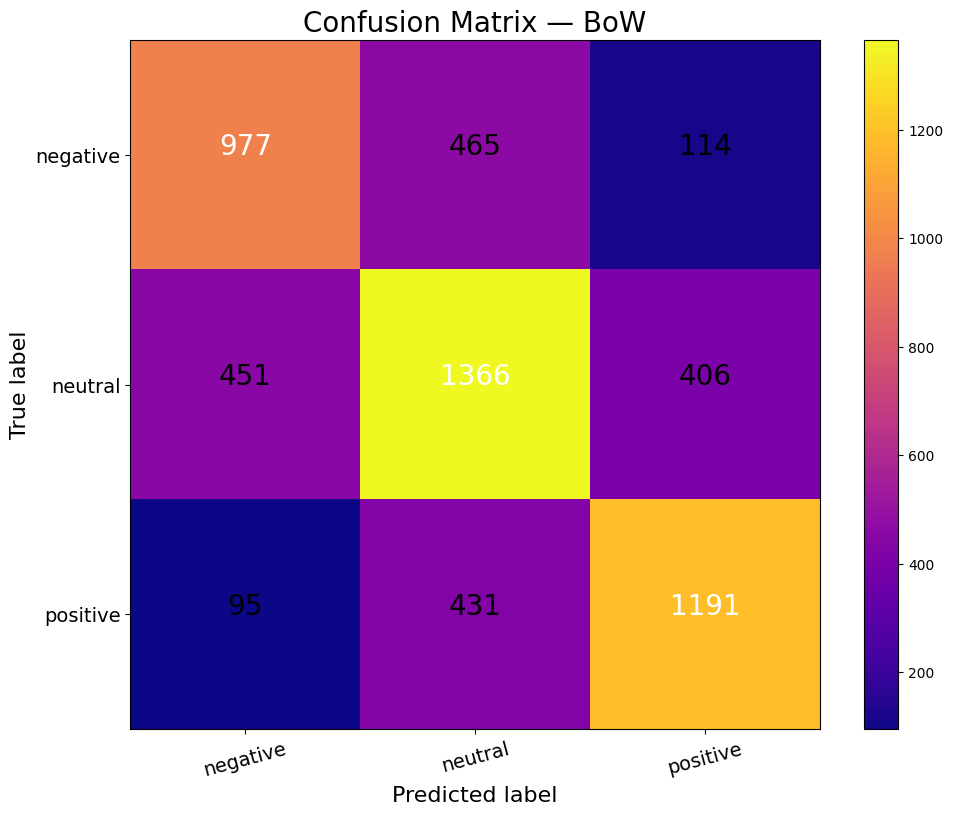

[[ 977  465  114]
 [ 451 1366  406]
 [  95  431 1191]]


In [42]:
def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=20)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, fontsize=14, rotation=15)
    plt.yticks(tick_marks, classes, fontsize=14)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black", fontsize=20)
    plt.tight_layout()
    plt.ylabel('True label', fontsize=16)
    plt.xlabel('Predicted label', fontsize=16)
    return plt

labels_sorted = sorted(clean_questions["sentiment"].unique())
cm = confusion_matrix(y_test, y_predicted_counts, labels=labels_sorted)
fig = plt.figure(figsize=(10, 8))
plot_confusion_matrix(cm, classes=labels_sorted, normalize=False,
                      title='Confusion Matrix — BoW', cmap="plasma")
plt.show()
print(cm)

### Наиболее значимые слова для каждого класса

In [43]:
def get_most_important_features(vectorizer, model, n=10):
    index_to_word = {v: k for k, v in vectorizer.vocabulary_.items()}
    classes = {}
    for class_index in range(model.coef_.shape[0]):
        word_importances = [(el, index_to_word[i])
                            for i, el in enumerate(model.coef_[class_index])]
        sorted_coeff = sorted(word_importances, key=lambda x: x[0], reverse=True)
        tops = sorted(sorted_coeff[:n], key=lambda x: x[0])
        bottom = sorted_coeff[-n:]
        classes[class_index] = {'tops': tops, 'bottom': bottom}
    return classes

importance = get_most_important_features(count_vectorizer, clf, 10)

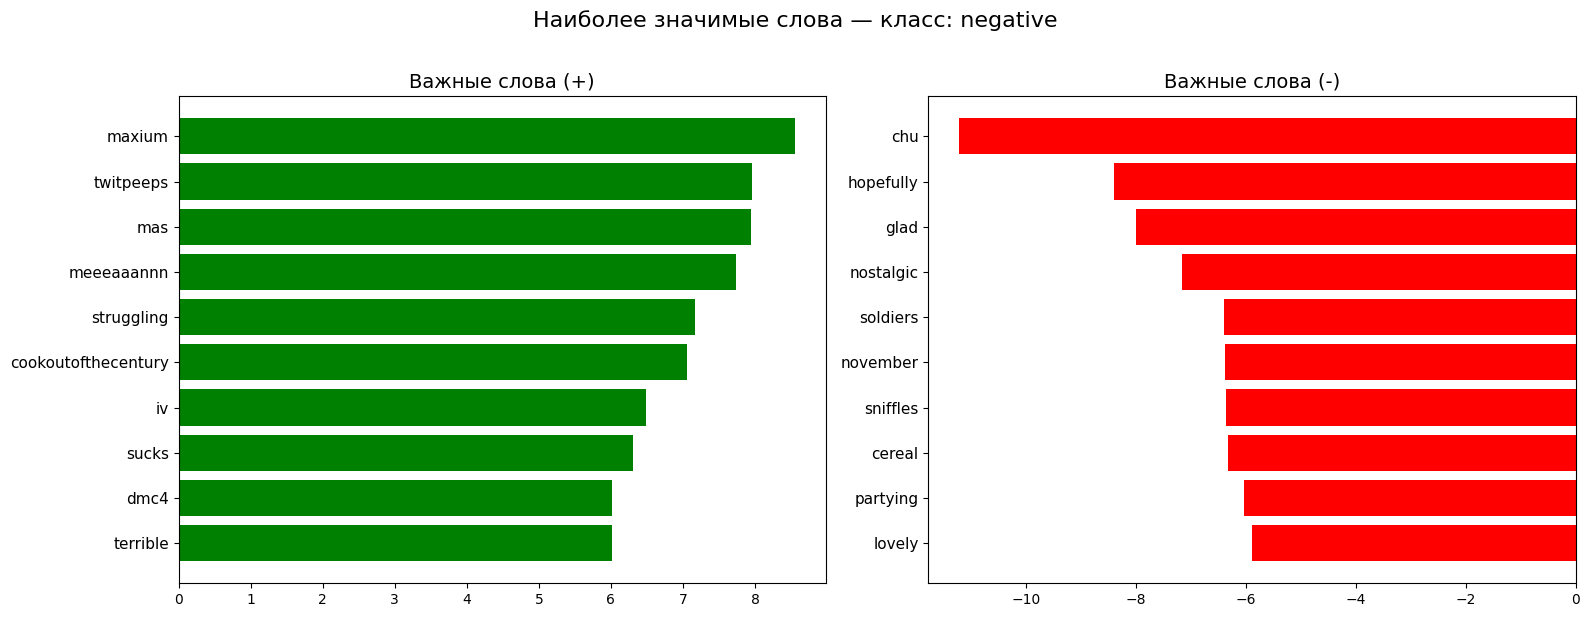

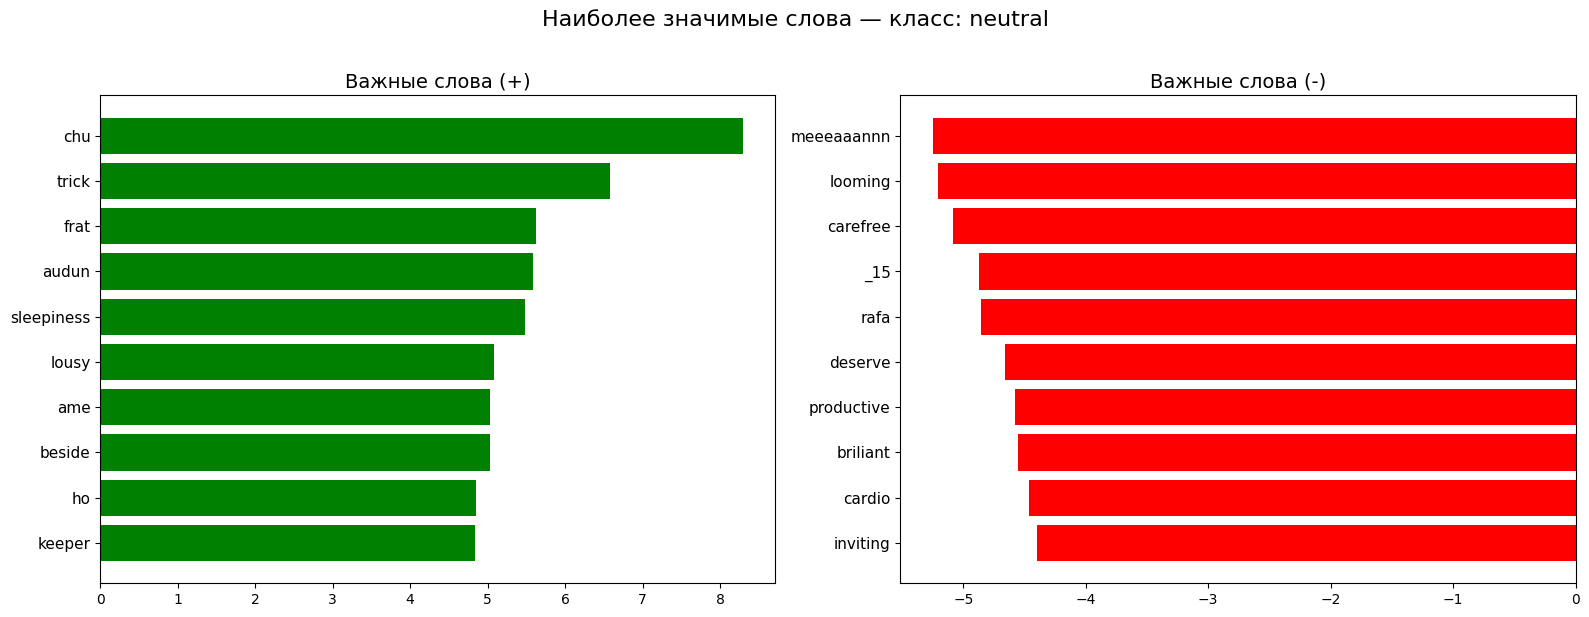

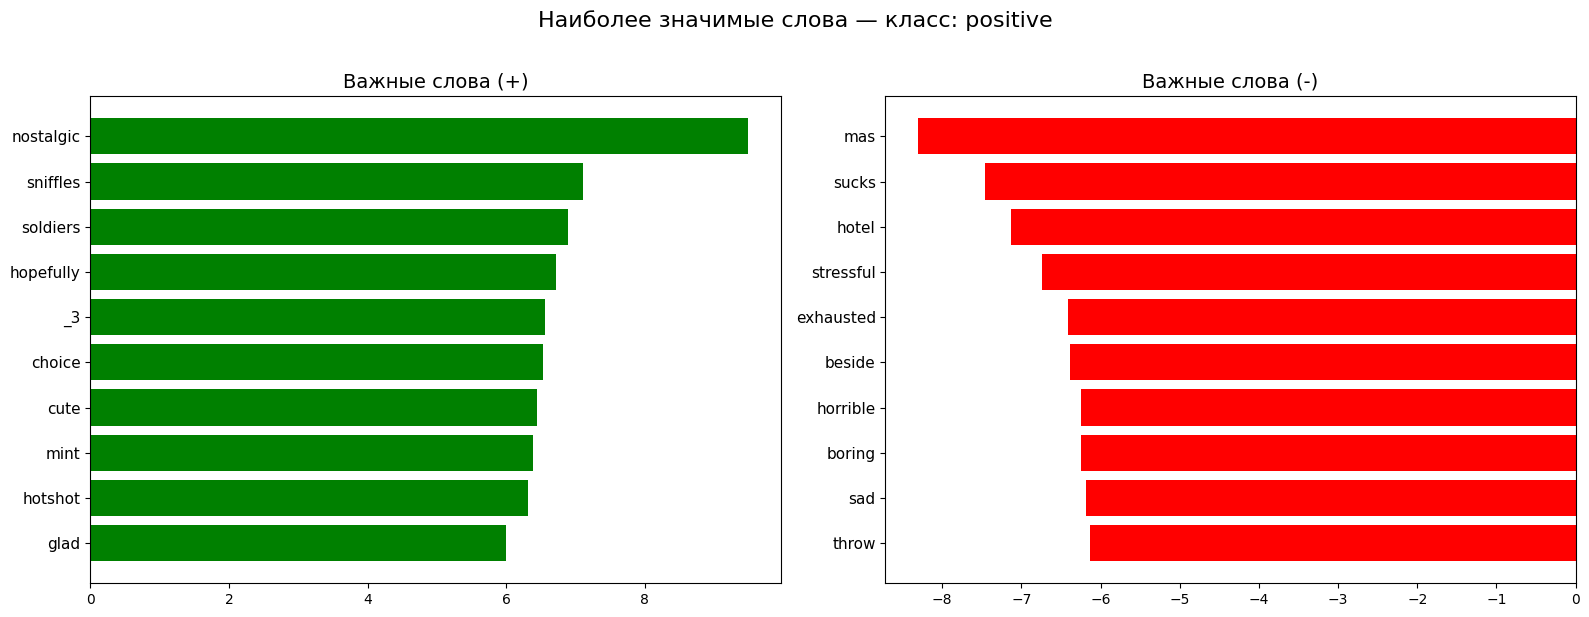

In [44]:
def plot_important_words(top_scores, top_words, bottom_scores, bottom_words, name):
    y_pos = np.arange(len(top_words))
    top_pairs = [(a, b) for a, b in zip(top_words, top_scores)]
    top_pairs = sorted(top_pairs, key=lambda x: x[1])

    bottom_pairs = [(a, b) for a, b in zip(bottom_words, bottom_scores)]
    bottom_pairs = sorted(bottom_pairs, key=lambda x: x[1], reverse=True)

    top_words = [a[0] for a in top_pairs]
    top_scores = [a[1] for a in top_pairs]

    bottom_words = [a[0] for a in bottom_pairs]
    bottom_scores = [a[1] for a in bottom_pairs]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors_top = ['green' if x > 0 else 'red' for x in top_scores]
    axes[0].barh(y_pos, top_scores, color=colors_top)
    axes[0].set_yticks(y_pos)
    axes[0].set_yticklabels(top_words, fontsize=11)
    axes[0].set_title('Важные слова (+)', fontsize=14)

    colors_bottom = ['green' if x > 0 else 'red' for x in bottom_scores]
    axes[1].barh(y_pos, bottom_scores, color=colors_bottom)
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(bottom_words, fontsize=11)
    axes[1].set_title('Важные слова (-)', fontsize=14)

    plt.suptitle(name, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

class_names = sorted(clean_questions['sentiment'].unique())
for i, class_name in enumerate(class_names):
    top_scores = [a[0] for a in importance[i]['tops']]
    top_words = [a[1] for a in importance[i]['tops']]
    bottom_scores = [a[0] for a in importance[i]['bottom']]
    bottom_words = [a[1] for a in importance[i]['bottom']]
    plot_important_words(top_scores, top_words, bottom_scores, bottom_words,
                         f"Наиболее значимые слова — класс: {class_name}")

## Шаг 6. TF-IDF

TF-IDF улучшает BoW: вместо простого счётчика учитывает, насколько слово важно для конкретного документа относительно всей коллекции. Частые слова во всём корпусе (например, "the") получают меньший вес.

In [45]:
def tfidf(data):
    tfidf_vectorizer = TfidfVectorizer()
    train = tfidf_vectorizer.fit_transform(data)
    return train, tfidf_vectorizer

X_train_tfidf, tfidf_vectorizer = tfidf(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

clf_tfidf = LogisticRegression(C=30.0, class_weight='balanced', solver='lbfgs',
                               max_iter=1000, random_state=RANDOM_SEED)
clf_tfidf.fit(X_train_tfidf, y_train)
y_predicted_tfidf = clf_tfidf.predict(X_test_tfidf)

accuracy2, precision2, recall2, f1_2 = get_metrics(y_test, y_predicted_tfidf)
print("TF-IDF + Logistic Regression:")
print("accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f" % (accuracy2, precision2, recall2, f1_2))
print()
print(classification_report(y_test, y_predicted_tfidf))

TF-IDF + Logistic Regression:
accuracy = 0.659, precision = 0.659, recall = 0.659, f1 = 0.659

              precision    recall  f1-score   support

    negative       0.66      0.65      0.65      1556
     neutral       0.62      0.62      0.62      2223
    positive       0.71      0.72      0.71      1717

    accuracy                           0.66      5496
   macro avg       0.66      0.66      0.66      5496
weighted avg       0.66      0.66      0.66      5496



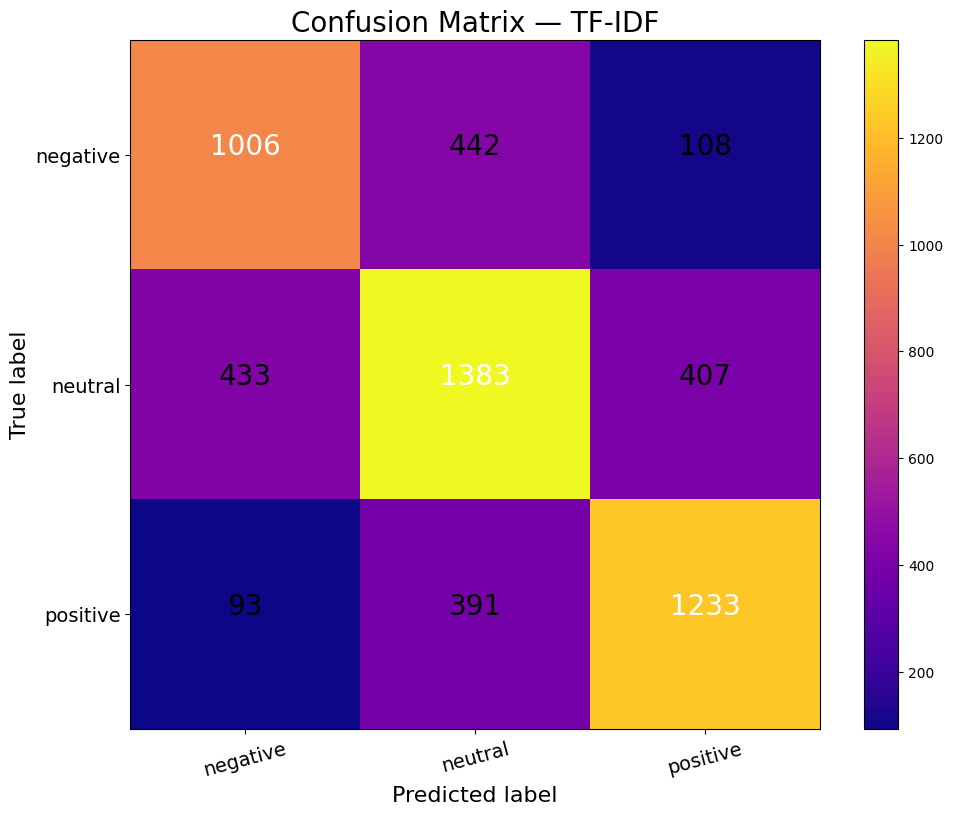

In [46]:
cm2 = confusion_matrix(y_test, y_predicted_tfidf, labels=labels_sorted)
fig = plt.figure(figsize=(10, 8))
plot_confusion_matrix(cm2, classes=labels_sorted, normalize=False,
                      title='Confusion Matrix — TF-IDF', cmap="plasma")
plt.show()

## Шаг 7. Word2Vec эмбеддинги

Word2Vec учит представлять слова как векторы в многомерном пространстве так, что семантически близкие слова оказываются рядом. Например, «хорошо» и «отлично» будут близкими векторами.

In [47]:
import gensim

tokenizer_w2v = RegexpTokenizer(r'\w+')
clean_questions["tokens"] = clean_questions["text"].apply(tokenizer_w2v.tokenize)

# Обучаем Word2Vec на нашем корпусе
word2vec = gensim.models.Word2Vec(
    clean_questions["tokens"].tolist(),
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    seed=RANDOM_SEED
)
print("Word2Vec обучен. Размер словаря:", len(word2vec.wv))

Word2Vec обучен. Размер словаря: 10288


In [48]:
# Пример: наиболее близкие слова к 'good'
try:
    print("Слова близкие к 'good':")
    print(word2vec.wv.most_similar('good', topn=5))
except KeyError:
    print("Слово не найдено в словаре")

Слова близкие к 'good':
[('nice', 0.913533627986908), ('great', 0.9054439663887024), ('everyone', 0.8692865371704102), ('fun', 0.8653752207756042), ('long', 0.8629487752914429)]


In [49]:
def get_average_word2vec(tokens_list, vector, generate_missing=False, k=300):
    """Усредняем векторы всех слов предложения"""
    if not tokens_list:
        return np.zeros(k)
    vectorized = []
    for word in tokens_list:
        if word in vector:
            vectorized.append(vector[word])
        elif generate_missing:
            vectorized.append(np.random.rand(k))
    if not vectorized:
        return np.zeros(k)
    return np.mean(vectorized, axis=0)

def get_word2vec_embeddings(vectors, clean_questions, generate_missing=False):
    embeddings = clean_questions['tokens'].apply(
        lambda x: get_average_word2vec(x, vectors, generate_missing=generate_missing)
    )
    return list(embeddings)

embeddings = get_word2vec_embeddings(word2vec.wv, clean_questions)
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    embeddings,
    list(clean_questions['sentiment']),
    test_size=0.2, random_state=RANDOM_SEED,
    stratify=list(clean_questions['sentiment'])
)
print("Train:", len(X_train_w2v), "Test:", len(X_test_w2v))

Train: 21983 Test: 5496


/tmp/ipykernel_5884/2676277139.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap("tab10", len(unique_labels))


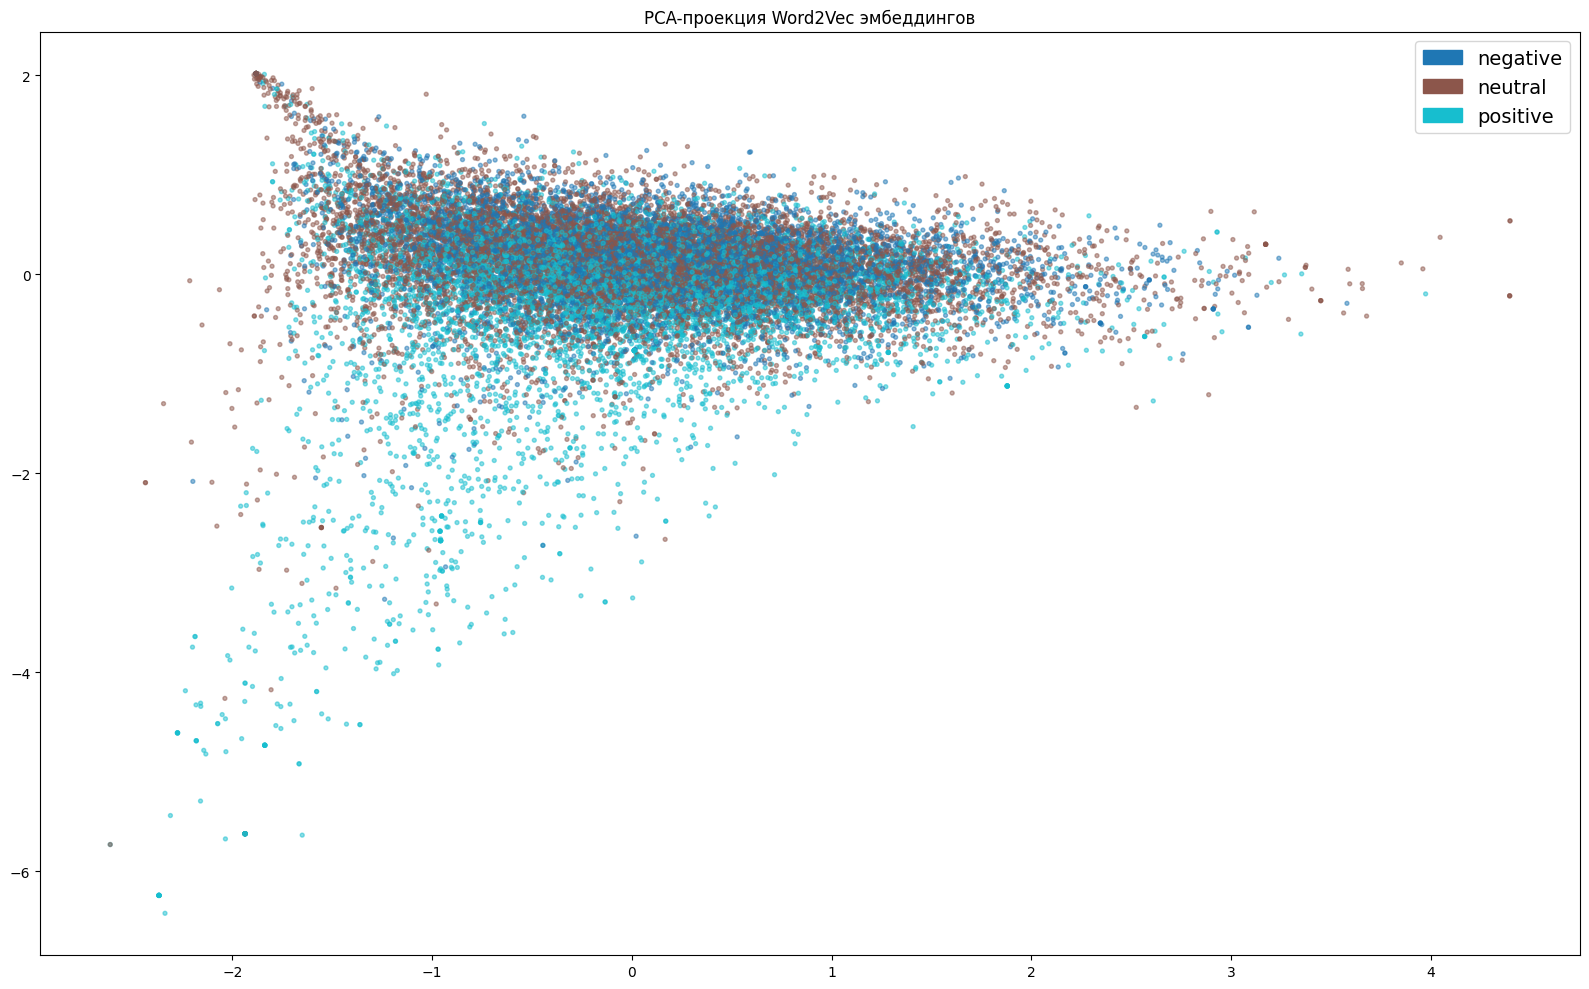

In [50]:
# Визуализация Word2Vec векторов
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_w2v_2d = pca.fit_transform(X_train_w2v)

unique_labels = sorted(set(y_train_w2v))
color_mapper = {label: idx for idx, label in enumerate(unique_labels)}
color_column = [color_mapper[label] for label in y_train_w2v]

cmap = matplotlib.cm.get_cmap("tab10", len(unique_labels))
fig = plt.figure(figsize=(16, 10))
plt.scatter(X_train_w2v_2d[:, 0], X_train_w2v_2d[:, 1], s=8, alpha=.5,
            c=color_column, cmap=cmap)
handles = [mpatches.Patch(color=cmap(i), label=label)
           for i, label in enumerate(unique_labels)]
plt.legend(handles=handles, prop={'size': 14})
plt.title('PCA-проекция Word2Vec эмбеддингов')
plt.tight_layout()
plt.show()

In [51]:
clf_w2v = LogisticRegression(C=30.0, class_weight='balanced', solver='lbfgs',
                             max_iter=1000, random_state=RANDOM_SEED)
clf_w2v.fit(X_train_w2v, y_train_w2v)
y_predicted_w2v = clf_w2v.predict(X_test_w2v)

accuracy_w2v, precision_w2v, recall_w2v, f1_w2v = get_metrics(y_test_w2v, y_predicted_w2v)
print("Word2Vec + Logistic Regression:")
print("accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f" % (accuracy_w2v, precision_w2v, recall_w2v, f1_w2v))
print()
print(classification_report(y_test_w2v, y_predicted_w2v))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Word2Vec + Logistic Regression:
accuracy = 0.573, precision = 0.576, recall = 0.573, f1 = 0.574

              precision    recall  f1-score   support

    negative       0.52      0.59      0.56      1556
     neutral       0.56      0.53      0.55      2223
    positive       0.64      0.61      0.63      1717

    accuracy                           0.57      5496
   macro avg       0.58      0.58      0.58      5496
weighted avg       0.58      0.57      0.57      5496



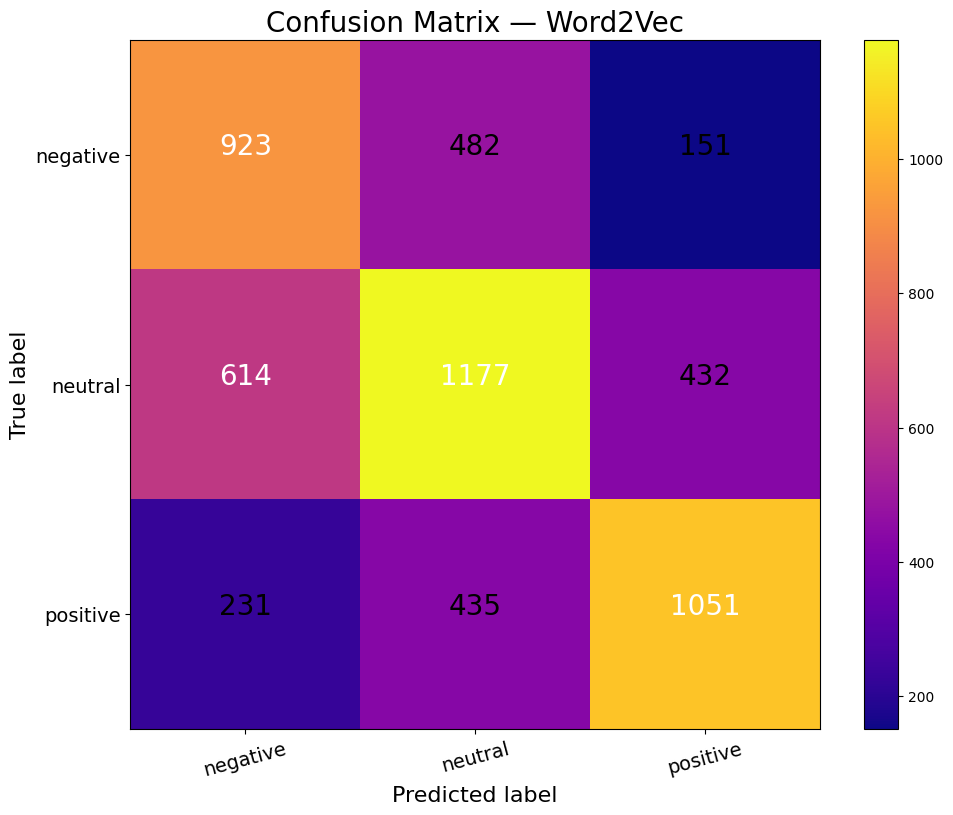

In [52]:
cm_w2v = confusion_matrix(y_test_w2v, y_predicted_w2v, labels=labels_sorted)
fig = plt.figure(figsize=(10, 8))
plot_confusion_matrix(cm_w2v, classes=labels_sorted, normalize=False,
                      title='Confusion Matrix — Word2Vec', cmap="plasma")
plt.show()

## Шаг 8. CNN для классификации текста

Сверточные нейронные сети умеют улавливать локальные паттерны в тексте (например, характерные n-граммы) и учитывают порядок слов, в отличие от BoW и TF-IDF.

In [53]:
try:
    from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.utils import to_categorical
    from tensorflow.keras.layers import Dense, Input, Flatten, Dropout, Concatenate
    from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
    from tensorflow.keras.models import Model
except ImportError:
    from keras.preprocessing.text import Tokenizer as KerasTokenizer
    from keras.preprocessing.sequence import pad_sequences
    from keras.utils import to_categorical
    from keras.layers import Dense, Input, Flatten, Dropout, Concatenate
    from keras.layers import Conv1D, MaxPooling1D, Embedding
    from keras.models import Model

EMBEDDING_DIM = 300
MAX_SEQUENCE_LENGTH = 35
VOCAB_SIZE = len(VOCAB)
VALIDATION_SPLIT = 0.2

keras_tokenizer = KerasTokenizer(num_words=VOCAB_SIZE)
keras_tokenizer.fit_on_texts(clean_questions["text"].tolist())
sequences = keras_tokenizer.texts_to_sequences(clean_questions["text"].tolist())

word_index = keras_tokenizer.word_index
print('Уникальных токенов:', len(word_index))

cnn_data = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Кодируем метки: negative=0, neutral=1, positive=2
label_encoder = {label: idx for idx, label in enumerate(sorted(clean_questions['sentiment'].unique()))}
numeric_labels = clean_questions['sentiment'].map(label_encoder).values
labels_cnn = to_categorical(numeric_labels)

indices = np.arange(cnn_data.shape[0])
np.random.seed(RANDOM_SEED)
np.random.shuffle(indices)
cnn_data = cnn_data[indices]
labels_cnn = labels_cnn[indices]

num_validation_samples = int(VALIDATION_SPLIT * cnn_data.shape[0])

# Матрица эмбеддингов из нашего Word2Vec
embedding_weights = np.zeros((len(word_index) + 1, EMBEDDING_DIM))
for word, index in word_index.items():
    if word in word2vec.wv:
        embedding_weights[index, :] = word2vec.wv[word]
    else:
        embedding_weights[index, :] = np.random.rand(EMBEDDING_DIM)
print("Матрица эмбеддингов:", embedding_weights.shape)

Уникальных токенов: 25193
Матрица эмбеддингов: (25194, 300)


In [54]:
def ConvNet(embeddings, max_sequence_length, num_words, embedding_dim, labels_index, trainable=False):
    embedding_layer = Embedding(
        num_words, embedding_dim,
        weights=[embeddings],
        input_length=max_sequence_length,
        trainable=trainable
    )
    sequence_input = Input(shape=(max_sequence_length,), dtype='int32')
    embedded_sequences = embedding_layer(sequence_input)

    # Yoon Kim (2014) — параллельные свёртки разных размеров
    convs = []
    for filter_size in [3, 4, 5]:
        l_conv = Conv1D(filters=128, kernel_size=filter_size, activation='relu')(embedded_sequences)
        l_pool = MaxPooling1D(pool_size=3)(l_conv)
        convs.append(l_pool)

    l_merge = Concatenate(axis=1)(convs)
    x = Dropout(0.5)(l_merge)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)

    preds = Dense(labels_index, activation='softmax')(x)

    model = Model(sequence_input, preds)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

x_train_cnn = cnn_data[:-num_validation_samples]
y_train_cnn = labels_cnn[:-num_validation_samples]
x_val_cnn = cnn_data[-num_validation_samples:]
y_val_cnn = labels_cnn[-num_validation_samples:]

model = ConvNet(
    embedding_weights,
    MAX_SEQUENCE_LENGTH,
    len(word_index) + 1,
    EMBEDDING_DIM,
    len(label_encoder)
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 35, 300)   │  7,558,200 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 33, 128)   │    115,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 32, 128)   │    153,728 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 31, 128)   │    192,128 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 11, 128)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 10, 128)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 10, 128)   │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 31, 128)   │          0 │ max_pooling1d[0]… │
│ (Concatenate)       │                   │            │ max_pooling1d_1[… │
│                     │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 31, 128)   │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3968)      │          0 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    508,032 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,527,803 (32.53 MB)

 Trainable params: 969,603 (3.70 MB)

 Non-trainable params: 7,558,200 (28.83 MB)

In [55]:
history_cnn = model.fit(
    x_train_cnn, y_train_cnn,
    validation_data=(x_val_cnn, y_val_cnn),
    epochs=5, batch_size=128
)

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 49s 257ms/step - accuracy: 0.4716 - loss: 1.0203 - val_accuracy: 0.5352 - val_loss: 0.9573
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 38s 223ms/step - accuracy: 0.5341 - loss: 0.9490 - val_accuracy: 0.5569 - val_loss: 0.9224
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 43s 250ms/step - accuracy: 0.5585 - loss: 0.9176 - val_accuracy: 0.5629 - val_loss: 0.9152
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 39s 225ms/step - accuracy: 0.5726 - loss: 0.8996 - val_accuracy: 0.5876 - val_loss: 0.8873
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 226ms/step - accuracy: 0.5913 - loss: 0.8815 - val_accuracy: 0.5927 - val_loss: 0.8735


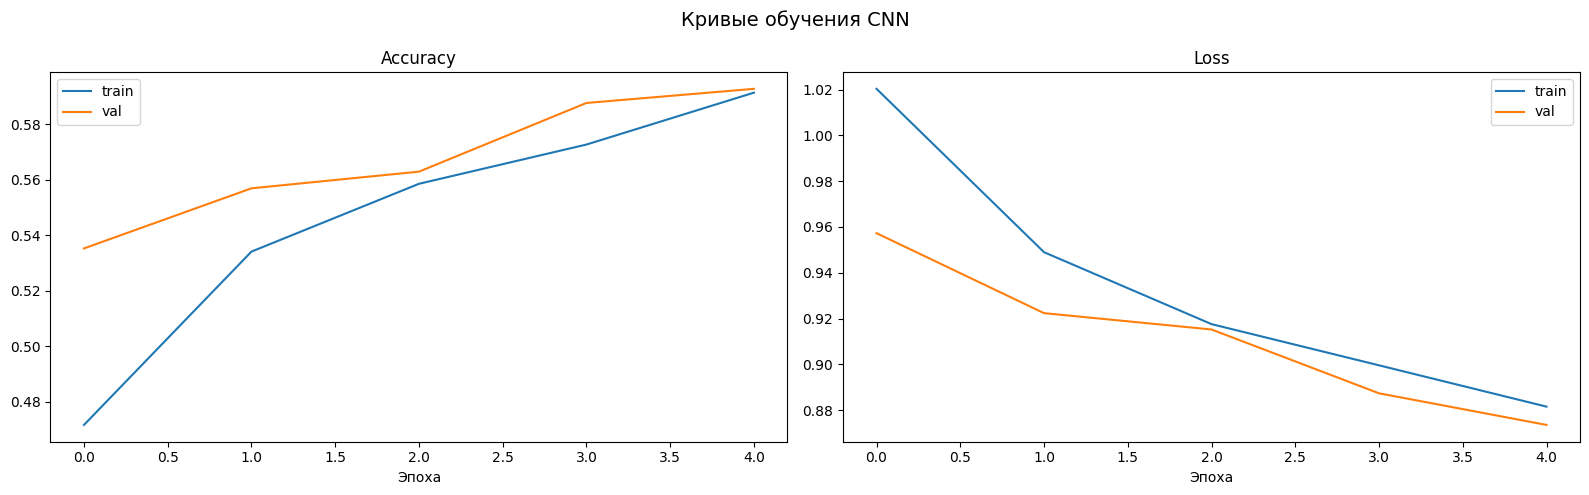

In [56]:
# Кривые обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(history_cnn.history['accuracy'], label='train')
ax1.plot(history_cnn.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Эпоха')
ax1.legend()

ax2.plot(history_cnn.history['loss'], label='train')
ax2.plot(history_cnn.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.set_xlabel('Эпоха')
ax2.legend()

plt.suptitle('Кривые обучения CNN', fontsize=14)
plt.tight_layout()
plt.show()

In [57]:
y_pred_cnn_prob = model.predict(x_val_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)
y_val_true = np.argmax(y_val_cnn, axis=1)

# Декодируем обратно в текстовые метки
idx_to_label = {v: k for k, v in label_encoder.items()}
y_pred_cnn_labels = [idx_to_label[i] for i in y_pred_cnn]
y_val_true_labels = [idx_to_label[i] for i in y_val_true]

accuracy_cnn, precision_cnn, recall_cnn, f1_cnn = get_metrics(y_val_true_labels, y_pred_cnn_labels)
print("CNN + Word2Vec:")
print("accuracy = %.3f, precision = %.3f, recall = %.3f, f1 = %.3f" % (accuracy_cnn, precision_cnn, recall_cnn, f1_cnn))
print()
print(classification_report(y_val_true_labels, y_pred_cnn_labels))

172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step
CNN + Word2Vec:
accuracy = 0.593, precision = 0.605, recall = 0.593, f1 = 0.585

              precision    recall  f1-score   support

    negative       0.57      0.39      0.46      1584
     neutral       0.54      0.75      0.63      2215
    positive       0.71      0.58      0.64      1696

    accuracy                           0.59      5495
   macro avg       0.61      0.57      0.58      5495
weighted avg       0.61      0.59      0.58      5495



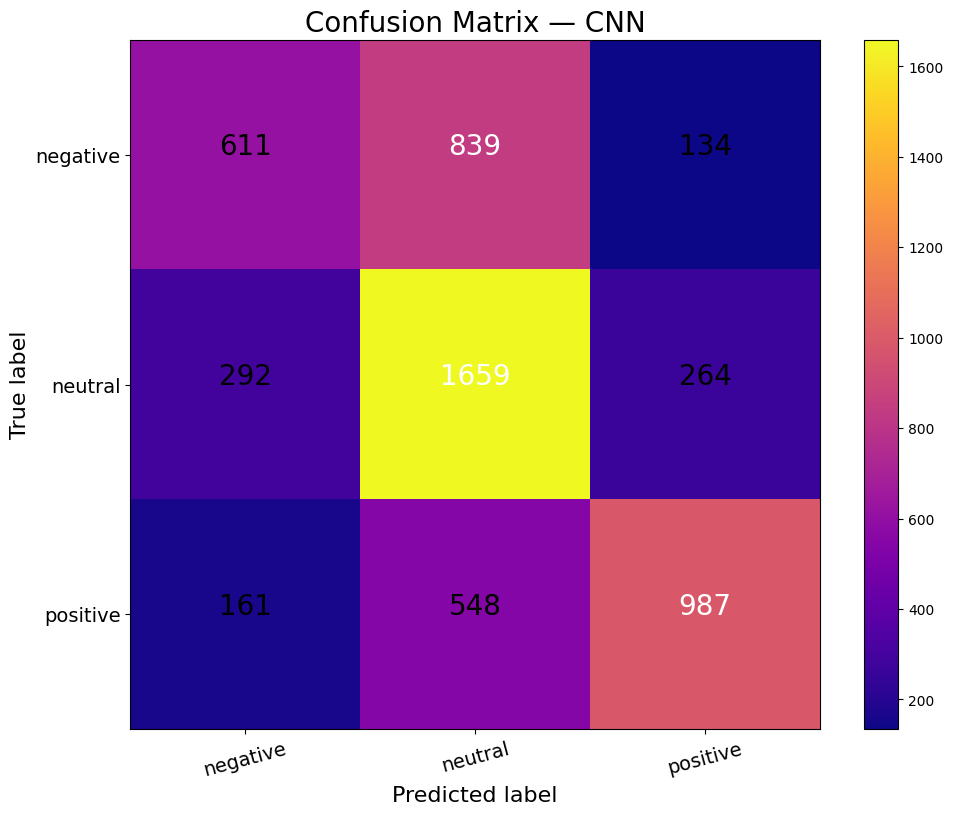

In [58]:
cm_cnn = confusion_matrix(y_val_true_labels, y_pred_cnn_labels, labels=labels_sorted)
fig = plt.figure(figsize=(10, 8))
plot_confusion_matrix(cm_cnn, classes=labels_sorted, normalize=False,
                      title='Confusion Matrix — CNN', cmap="plasma")
plt.show()

## Шаг 9. Сравнение всех моделей

                   Accuracy  Precision  Recall     F1
Модель                                               
BoW + LogReg          0.643      0.643   0.643  0.643
TF-IDF + LogReg       0.659      0.659   0.659  0.659
Word2Vec + LogReg     0.573      0.576   0.573  0.574
CNN + Word2Vec        0.593      0.605   0.593  0.585


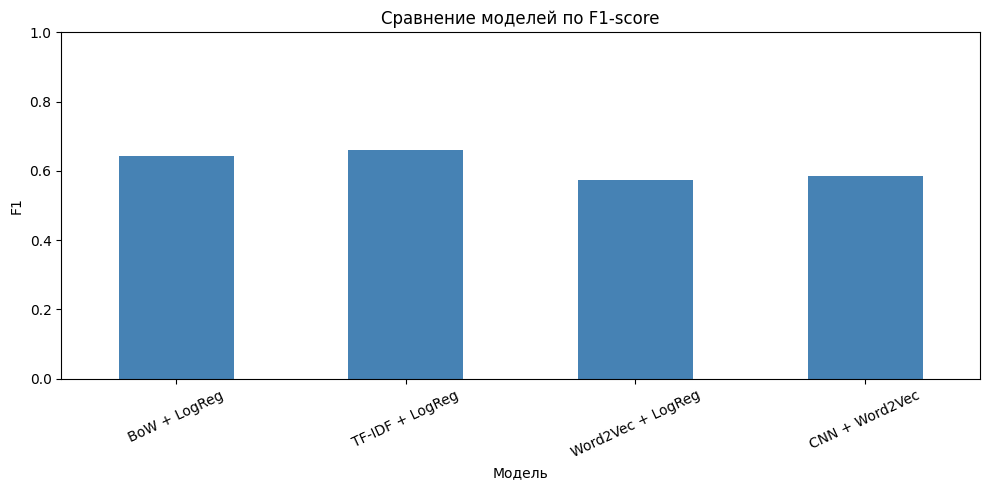

In [59]:
results = pd.DataFrame({
    'Модель': ['BoW + LogReg', 'TF-IDF + LogReg', 'Word2Vec + LogReg', 'CNN + Word2Vec'],
    'Accuracy': [accuracy, accuracy2, accuracy_w2v, accuracy_cnn],
    'Precision': [precision, precision2, precision_w2v, precision_cnn],
    'Recall': [recall, recall2, recall_w2v, recall_cnn],
    'F1': [f1, f1_2, f1_w2v, f1_cnn]
})
results = results.set_index('Модель')
print(results.round(3))

results['F1'].plot(kind='bar', rot=25, color='steelblue', figsize=(10, 5))
plt.title('Сравнение моделей по F1-score')
plt.ylabel('F1')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Выводы

1. **Bag of Words + Logistic Regression** — самый простой базовый метод. Игнорирует порядок слов и семантику, но быстро обучается и легко интерпретируется.

2. **TF-IDF + Logistic Regression** — улучшение BoW: частые во всём корпусе слова получают меньший вес, что повышает качество.

3. **Word2Vec + Logistic Regression** — слова представляются плотными векторами, улавливающими семантическую близость. Усреднение векторов предложения теряет порядок слов, но учитывает смысл.

4. **CNN + Word2Vec** — нейронная сеть учитывает порядок слов и локальные паттерны (n-граммы), что как правило даёт наилучший результат.

